<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/IPL-Statistical-Analysis/blob/main/notebooks/IPL_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and Prepare Data

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/ipl_data.csv')
df.sample(5)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
289,290,2011,Indore,2011-05-13,Kochi Tuskers Kerala,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KD Karthik,Holkar Cricket Stadium,S Asnani,RJ Tucker,NaN
186,187,2010,Ahmedabad,2010-03-20,Rajasthan Royals,Kolkata Knight Riders,Rajasthan Royals,bat,normal,0,Rajasthan Royals,34,0,AA Jhunjhunwala,"Sardar Patel Stadium, Motera",RE Koertzen,RB Tiffin,NaN
188,189,2010,Cuttack,2010-03-21,Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,normal,0,Deccan Chargers,10,0,A Symonds,Barabati Stadium,BF Bowden,M Erasmus,NaN
66,67,2008,Chennai,2008-04-23,Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,normal,0,Chennai Super Kings,6,0,ML Hayden,"MA Chidambaram Stadium, Chepauk",DJ Harper,GA Pratapkumar,NaN
561,562,2015,Mumbai,2015-05-10,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,39,0,AB de Villiers,Wankhede Stadium,JD Cloete,C Shamshuddin,NaN


In [ ]:
df = df[['id','season', 'toss_winner', 'toss_decision', 'winner']]
df.sample(5)

,id,season,toss_winner,toss_decision,winner
76,77,2008,Kings XI Punjab,field,Kings XI Punjab
443,444,2013,Sunrisers Hyderabad,bat,Mumbai Indians
389,390,2013,Mumbai Indians,bat,Mumbai Indians
226,227,2010,Rajasthan Royals,bat,Kolkata Knight Riders
27,28,2017,Mumbai Indians,field,Rising Pune Supergiant


In [ ]:
df['winner'].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Mumbai Indians',
       'Delhi Daredevils', 'Gujarat Lions', 'Chennai Super Kings',
       'Rajasthan Royals', 'Deccan Chargers', 'Pune Warriors',
       'Kochi Tuskers Kerala', nan, 'Rising Pune Supergiants'],
      dtype=object)

In [ ]:
df = df.dropna(subset=['winner'])
df['winner'].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Mumbai Indians',
       'Delhi Daredevils', 'Gujarat Lions', 'Chennai Super Kings',
       'Rajasthan Royals', 'Deccan Chargers', 'Pune Warriors',
       'Kochi Tuskers Kerala', 'Rising Pune Supergiants'], dtype=object)

In [ ]:
# Create indicator variable
# 1 = Toss winner also won match
# 0 = Toss winner lost match
df['toss_match_win'] = (df['toss_winner'] == df['winner']).astype(int)
display(df.head())
print("\nTotal Matches:", len(df))

,id,season,toss_winner,toss_decision,winner,toss_match_win
0,1,2017,Royal Challengers Bangalore,field,Sunrisers Hyderabad,0
1,2,2017,Rising Pune Supergiant,field,Rising Pune Supergiant,1
2,3,2017,Kolkata Knight Riders,field,Kolkata Knight Riders,1
3,4,2017,Kings XI Punjab,field,Kings XI Punjab,1
4,5,2017,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,1



Total Matches: 633


#Population Analysis

In [ ]:
N = len(df)
x = df['toss_match_win'].sum()

p_hat_population = x / N

print("Total Matches:", N)
print("Matches where Toss Winner Won:", x)
print("Population Proportion:", round(p_hat_population, 4))

Total Matches: 633
Matches where Toss Winner Won: 325
Population Proportion: 0.5134


#Using Various Sampling techniques

##Simple Random Sampling (SRS)

In [ ]:
np.random.seed(42)

n = 200

srs_sample = df.sample(n=n, random_state=42)

p_srs = srs_sample['toss_match_win'].mean()

print("SRS Proportion:", round(p_srs,4))

SRS Proportion: 0.52


##Systematic Sampling

In [ ]:
k = len(df) // n

systematic_sample = df.iloc[::k]

# ensure sample size near 200
systematic_sample = systematic_sample.head(n)

p_systematic = systematic_sample['toss_match_win'].mean()

print("Systematic Proportion:", round(p_systematic,4))

Systematic Proportion: 0.495


##Stratified Sampling (Season-wise)

In [ ]:
stratified_sample = (
    df.groupby('season', group_keys=False)
      .apply(lambda x: x.sample(
          max(1, int(len(x)*n/len(df))),
          random_state=42
      ))
)

p_stratified = stratified_sample['toss_match_win'].mean()

print("Stratified Proportion:", round(p_stratified,4))
print("Sample Size:", len(stratified_sample))

Stratified Proportion: 0.5179
Sample Size: 195


##Comparing Sampling techniques

In [ ]:
comparison = pd.DataFrame({
    'Sampling Method': ['Population','SRS','Systematic','Stratified'],
    'Estimated Proportion': [
        p_hat_population,
        p_srs,
        p_systematic,
        p_stratified
    ]
})

display(comparison)

,Sampling Method,Estimated Proportion
0,Population,0.513428
1,SRS,0.520000
2,Systematic,0.495000
3,Stratified,0.517949


#Confidence Interval

In [ ]:
from scipy.stats import norm

#Assuming: We are 95% confident that the true probability of a toss winner winning the match lies within this interval.
z = norm.ppf(0.975)

p_hat = p_srs

se = np.sqrt((p_hat*(1-p_hat))/n)

lower = p_hat - z*se
upper = p_hat + z*se

print("95% Confidence Interval")
print(f"({lower:.4f}, {upper:.4f})")

95% Confidence Interval
(0.4508, 0.5892)


#Hypothesis Testing

##1️⃣ Does winning the toss increase probability of winning?

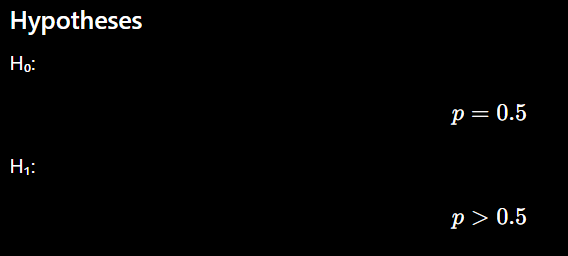

Observation: Right Tail test

In [ ]:
from scipy.stats import norm

p0 = 0.5

z_stat = (p_hat - p0) / np.sqrt((p0*(1-p0))/n)

p_value = 1 - norm.cdf(z_stat)

print("Z Statistic:", round(z_stat,4))
print("P-value:", round(p_value,6))

Z Statistic: 0.5657
P-value: 0.285804


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Winning the toss significantly increases the probability of winning.")
else:
    print("Fail to Reject H0")
    print("No significant evidence that winning the toss increases the probability of winning.")

Fail to Reject H0
No significant evidence that winning the toss increases the probability of winning.


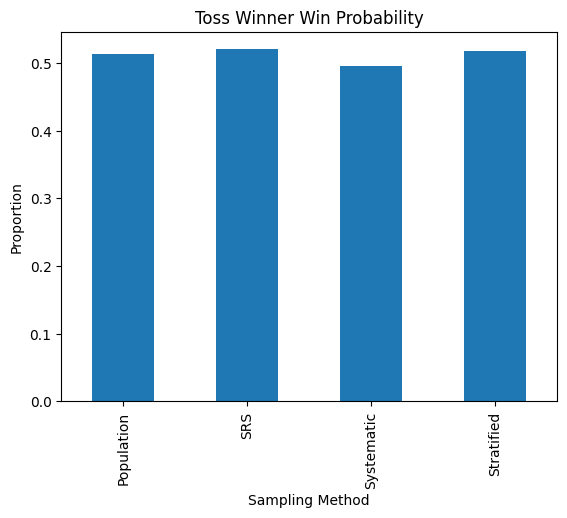

In [ ]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Sampling Method',
    y='Estimated Proportion',
    kind='bar',
    legend=False
)

plt.ylabel("Proportion")
plt.title("Toss Winner Win Probability")
plt.show()

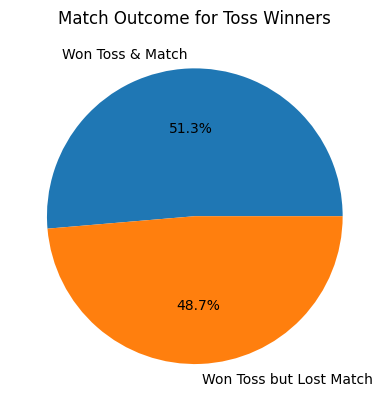

In [ ]:
counts = df['toss_match_win'].value_counts()

plt.pie(
    counts,
    labels=['Won Toss & Match','Won Toss but Lost Match'],
    autopct='%1.1f%%'
)

plt.title("Match Outcome for Toss Winners")
plt.show()

#Matches and Deliveries Dataset

In [ ]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

#2️⃣Do team batting first score more runs than team batting second

POPULATION ANALYSIS
----------------------------------------
Matches: 1092
Mean First Innings Score: 165.55
Mean Second Innings Score: 152.19

SRS SAMPLE ANALYSIS
----------------------------------------
Sample Mean First Innings: 161.58
Sample Mean Second Innings: 148.97

95% CONFIDENCE INTERVALS
----------------------------------------
First Innings: (157.24, 165.92)
Second Innings: (144.58, 153.36)

HYPOTHESIS TEST
----------------------------------------
H0 : μ1 = μ2
H1 : μ1 ≠ μ2

t-statistic: 4.0271
p-value: 6.8e-05

Reject H0
Significant difference exists between first and second innings scores.

Cohen's d: 0.4027


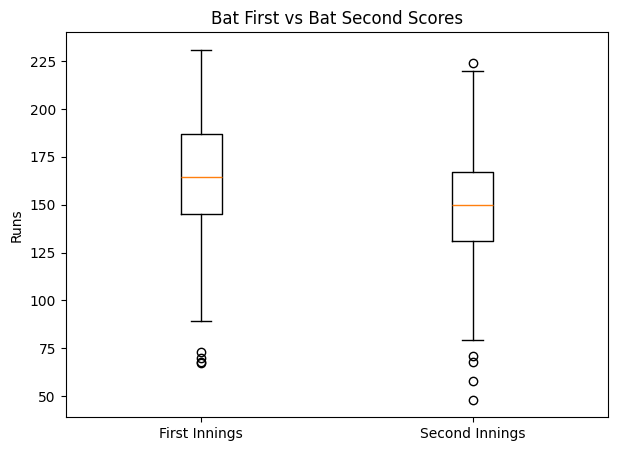

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_ind

# ============================
# Prepare Data
# ============================

innings_scores = (
    deliveries.groupby(['match_id', 'inning'])['total_runs']
    .sum()
    .reset_index()
)

first_innings = innings_scores[
    innings_scores['inning'] == 1
]['total_runs']

second_innings = innings_scores[
    innings_scores['inning'] == 2
]['total_runs']

# ============================
# Population Analysis
# ============================

print("POPULATION ANALYSIS")
print("-"*40)

print("Matches:",
      min(len(first_innings), len(second_innings)))

print("Mean First Innings Score:",
      round(first_innings.mean(),2))

print("Mean Second Innings Score:",
      round(second_innings.mean(),2))

# ============================
# SRS Sampling
# ============================

np.random.seed(42)

n = 200

sample_first = first_innings.sample(
    n=min(n,len(first_innings)),
    random_state=42
)

sample_second = second_innings.sample(
    n=min(n,len(second_innings)),
    random_state=42
)

mean1 = sample_first.mean()
mean2 = sample_second.mean()

print("\nSRS SAMPLE ANALYSIS")
print("-"*40)

print("Sample Mean First Innings:",
      round(mean1,2))

print("Sample Mean Second Innings:",
      round(mean2,2))

# ============================
# Confidence Intervals
# ============================

def confidence_interval(data):

    n = len(data)

    mean = np.mean(data)

    se = np.std(data,ddof=1)/np.sqrt(n)

    margin = (
        t.ppf(0.975,n-1)
        * se
    )

    return mean-margin, mean+margin

ci_first = confidence_interval(sample_first)
ci_second = confidence_interval(sample_second)

print("\n95% CONFIDENCE INTERVALS")
print("-"*40)

print(
    f"First Innings: ({ci_first[0]:.2f}, {ci_first[1]:.2f})"
)

print(
    f"Second Innings: ({ci_second[0]:.2f}, {ci_second[1]:.2f})"
)

# ============================
# Hypothesis Testing
# ============================

print("\nHYPOTHESIS TEST")
print("-"*40)

print("H0 : μ1 = μ2")
print("H1 : μ1 ≠ μ2")

t_stat, p_value = ttest_ind(
    sample_first,
    sample_second,
    equal_var=False
)

print("\nt-statistic:",
      round(t_stat,4))

print("p-value:",
      round(p_value,6))

alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("Significant difference exists between first and second innings scores.")
else:
    print("\nFail to Reject H0")
    print("No significant difference exists between first and second innings scores.")

# ============================
# Effect Size
# ============================

pooled_sd = np.sqrt(
    (
        np.var(sample_first,ddof=1)
        +
        np.var(sample_second,ddof=1)
    ) / 2
)

cohens_d = (
    mean1 - mean2
) / pooled_sd

print("\nCohen's d:",
      round(cohens_d,4))

# ============================
# Visualization
# ============================

plt.figure(figsize=(7,5))

plt.boxplot(
    [sample_first, sample_second],
    labels=[
        'First Innings',
        'Second Innings'
    ]
)

plt.ylabel("Runs")
plt.title("Bat First vs Bat Second Scores")

plt.show()

#3️⃣Wickets per over follow a Poisson distribution

PARAMETER ESTIMATION
----------------------------------------
Estimated λ (mean wickets per over): 0.3068

CHI-SQUARE GOODNESS OF FIT
----------------------------------------
Chi-Square Statistic: 52.5481
P-value: 0.0

HYPOTHESIS TEST
----------------------------------------
H0 : Wickets per over follow a Poisson distribution
H1 : Wickets per over do NOT follow a Poisson distribution

Reject H0
Poisson distribution is NOT a good fit.

Observed vs Expected Frequencies


,Observed,Expected
0,30810,31058.59
1,9981,9528.75
2,1299,1461.71
3,109,149.48
4,11,11.47


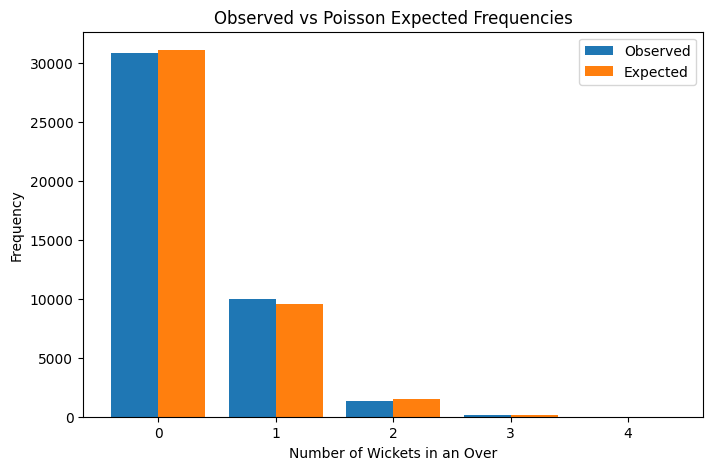

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chisquare

# ==================================
# Prepare Data
# ==================================

wickets = deliveries[
    deliveries['player_dismissed'].notna()
].copy()

# Count wickets per over
wickets_per_over = (
    wickets.groupby(['match_id','inning','over'])
    .size()
    .reset_index(name='wickets')
)

# Include overs with zero wickets
all_overs = (
    deliveries[['match_id','inning','over']]
    .drop_duplicates()
)

wickets_per_over = (
    all_overs.merge(
        wickets_per_over,
        on=['match_id','inning','over'],
        how='left'
    )
)

wickets_per_over['wickets'] = (
    wickets_per_over['wickets']
    .fillna(0)
    .astype(int)
)

# ==================================
# Parameter Estimation
# ==================================

lambda_hat = wickets_per_over['wickets'].mean()

print("PARAMETER ESTIMATION")
print("-"*40)

print("Estimated λ (mean wickets per over):",
      round(lambda_hat,4))

# ==================================
# Observed Frequencies
# ==================================

observed = (
    wickets_per_over['wickets']
    .value_counts()
    .sort_index()
)

max_wickets = observed.index.max()

k_values = np.arange(0, max_wickets + 1)

observed_freq = np.array([
    observed.get(k,0)
    for k in k_values
])

# ==================================
# Expected Frequencies
# ==================================

n = len(wickets_per_over)

expected_prob = poisson.pmf(
    k_values,
    mu=lambda_hat
)

expected_freq = expected_prob * n

# combine tail categories if needed
while np.any(expected_freq < 5) and len(expected_freq) > 2:

    expected_freq[-2] += expected_freq[-1]
    observed_freq[-2] += observed_freq[-1]

    expected_freq = expected_freq[:-1]
    observed_freq = observed_freq[:-1]

# normalize
expected_freq = (
    expected_freq *
    (observed_freq.sum()/expected_freq.sum())
)

# ==================================
# Chi-Square Goodness of Fit Test
# ==================================

chi2_stat, p_value = chisquare(
    observed_freq,
    expected_freq
)

print("\nCHI-SQUARE GOODNESS OF FIT")
print("-"*40)

print("Chi-Square Statistic:",
      round(chi2_stat,4))

print("P-value:",
      round(p_value,6))

# ==================================
# Hypothesis Test
# ==================================

print("\nHYPOTHESIS TEST")
print("-"*40)

print("H0 : Wickets per over follow a Poisson distribution")
print("H1 : Wickets per over do NOT follow a Poisson distribution")

alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("Poisson distribution is NOT a good fit.")
else:
    print("\nFail to Reject H0")
    print("Poisson distribution provides a reasonable fit.")

# ==================================
# Comparison Table
# ==================================

comparison = pd.DataFrame({
    'Observed': observed_freq,
    'Expected': np.round(expected_freq,2)
})

print("\nObserved vs Expected Frequencies")
display(comparison)

# ==================================
# Visualization
# ==================================

x = np.arange(len(observed_freq))

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    observed_freq,
    width=0.4,
    label='Observed'
)

plt.bar(
    x + 0.2,
    expected_freq,
    width=0.4,
    label='Expected'
)

plt.xlabel("Number of Wickets in an Over")
plt.ylabel("Frequency")
plt.title("Observed vs Poisson Expected Frequencies")
plt.legend()

plt.show()